In [5]:
import warnings
warnings.filterwarnings("ignore")

import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pandas as pd
import glob
import yaml
import astropy.wcs.wcs as wcs
from astropy.nddata import Cutout2D

import sys
sys.path.append(os.path.abspath(".."))
from scripts._create_figs import create_m0_map, create_m8_map, create_fig, mark_sources, create_cont_map, plot_vector, getIdx, plot_outflow_and_separation_vectors

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)
IMAGE_DIRECTORY = config["data_dir"]

In [6]:
# SET OUTPUT
output_folder = "test"
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

# READ DATA
outflow_data = pd.read_csv('../data/output/outflow_data.csv')
outflow_data2 = outflow_data.groupby('field').first().reset_index()
by_field = pd.read_csv('../data/output/data_by_field.csv')
source_info = pd.read_csv("../data/output/source_info.csv", index_col='Main')
source_info.index = source_info.index.str.casefold()

cont_files = glob.glob(f'{IMAGE_DIRECTORY}/*/*cont*.fits')
spw39_files = glob.glob(f'{IMAGE_DIRECTORY}/*/*12co*.fits') + glob.glob(f'{IMAGE_DIRECTORY}/*/*spw39*.fits')
if len(cont_files) != len(spw39_files):
    raise ValueError("Number of continuum files does not match number of 12CO/SPW39 files.")

# SCRIPT
# define fields in each figure
fig_1 = ['HOPS-32', 'HOPS-168', 'HOPS-281', 'Per-emb-17']
fig_2 = ['HOPS-290', 'HOPS-288']
no_outflows = ['HOPS-28', 'HOPS-163', 'HOPS-242', 'HOPS-255', 'HOPS-248', 'HOPS-357']
app_1 = by_field[~by_field['field'].isin(no_outflows)]['field'].values
app_2 = by_field[by_field['field'].isin(no_outflows)]['field'].values

In [7]:
def make_compound_plots(field_list, output_name, rows, cols, wspace=0.35, hspace=0.2):
    figure = plt.figure(figsize=(17/3*cols, 22/5*rows))

    # This loops through each source field with an angle measurement and creates
    # a figure with the separation vector and outflow vector overlayed

    data = by_field[by_field['field'].isin(field_list)]

    subplot_num = 1
    
    for i, field in data.sort_values(by='ra', ascending=True).reset_index().iterrows():

        # verify output path exists and
        # skip already existing files if you don't want to overwrite them
        target_name = field['field']

        # verify output path exists and
        if not os.path.exists(output_folder):
            os.mkdir(output_folder)

        # open images
        spw39_file = spw39_files[next((i for i, s in enumerate(spw39_files) if target_name.casefold() in s), None)]
        cont_file = cont_files[next((i for i, s in enumerate(cont_files) if target_name.casefold() in s), None)]
        hdu_cont = fits.open(cont_file)[0]
        hdu_spw39 = fits.open(spw39_file)[0]
        distance = source_info.loc[target_name.casefold(), 'Dis'].iloc[0]
        target_info = source_info.loc[target_name.casefold()]

        # MOMENT MAP PANEL
        # M8 Map
        if pd.isna(field['integrated_channels']):
            # Create Figure
            fig = create_m8_map(hdu_spw39, distance=distance, figure=figure, subplot=(rows, cols, subplot_num), multiimage=True)
            fig.set_title(f"{target_name} M8")   
        
        # M0 Map
        else:
            # Create Figure
            outflow = outflow_data.loc[outflow_data['field'] == target_name].groupby('field').first().reset_index()
            channels = getIdx([outflow.at[0, 'red_channels'], outflow.at[0, 'blue_channels']])
            fig = create_m0_map(hdu_spw39, channels, sigma=3, distance=distance, figure=figure, subplot=(rows, cols, subplot_num), multiimage=True)
            fig.set_title(f"{target_name} M0")

            # Plot Vectors
            plot_outflow_and_separation_vectors(fig, outflow_data, target_name)

        # Mark Sources
        mark_sources(fig, target_info, fontsize=8, use_short_label=True)

        # Manage Axis Labels
        if not str(output_name).startswith("appendix"):
            if (subplot_num-1) % cols != cols - 1:
                fig.colorbar.set_axis_label_text("")
        if (subplot_num-1) % cols != 0:
            fig.axis_labels.hide_y()
        if (rows > 1) & ((subplot_num-1) < rows*cols - cols):
            fig.axis_labels.hide_x()

        # CONTINUUM PANEL
        subplot_num += cols

        distance = target_info.iloc[0]['Dis']
        size = np.array([800/distance, 800/distance]) * u.arcsecond
        fig1 = create_cont_map(hdu_cont, size=size, distance=distance, scalebar_au=100, figure=figure, subplot=(rows, cols, subplot_num), multiimage=True)
        fig1.scalebar.set_color('white')
        fig1.set_title(f"{target_name} Continuum (Zoom-in)")

        # mark sources
        mark_sources(fig1, target_info, fontsize=8, use_short_label=True)

        # manage axis labels
        if not str(output_name).startswith("appendix"):
            if (subplot_num-1) % cols != cols - 1:
                fig1.colorbar.set_axis_label_text("")
        if (subplot_num-1) % cols != 0:
            fig1.axis_labels.hide_y()
        if (rows > 1) & ((subplot_num-1) < rows*cols - cols):
            fig1.axis_labels.hide_x()

        subplot_num -= (cols - 1)
        if (i+1) % cols == 0:
            subplot_num += cols

    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    # save image
    figure.savefig(os.path.join(output_folder, f"{output_name}.pdf"), bbox_inches='tight')
    # figure.savefig(os.path.join(output_folder, f"{output_name}.png"), dpi=800, transparent=True, bbox_inches='tight')
    figure.show()

INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  5.004e-01 [aplpy.core]
INFO: Auto-setting vmin to -1.804e-04 [aplpy.core]
INFO: Auto-setting vmax to  1.120e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  8.602e-01 [aplpy.core]
INFO: Auto-setting vmin to -7.830e-05 [aplpy.core]
INFO: Auto-setting vmax to  2.764e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  7.112e-01 [aplpy.core]
INFO: Auto-setting vmin to -6.060e-05 [aplpy.core]
INFO: Auto-setting vmax to  4.669e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.819e-01 [aplpy.core]
INFO: Auto-setting vmin to -2.056e-04 [aplpy.core]
INFO: Auto-setting vmax to  1.303e-02 [aplpy.core]


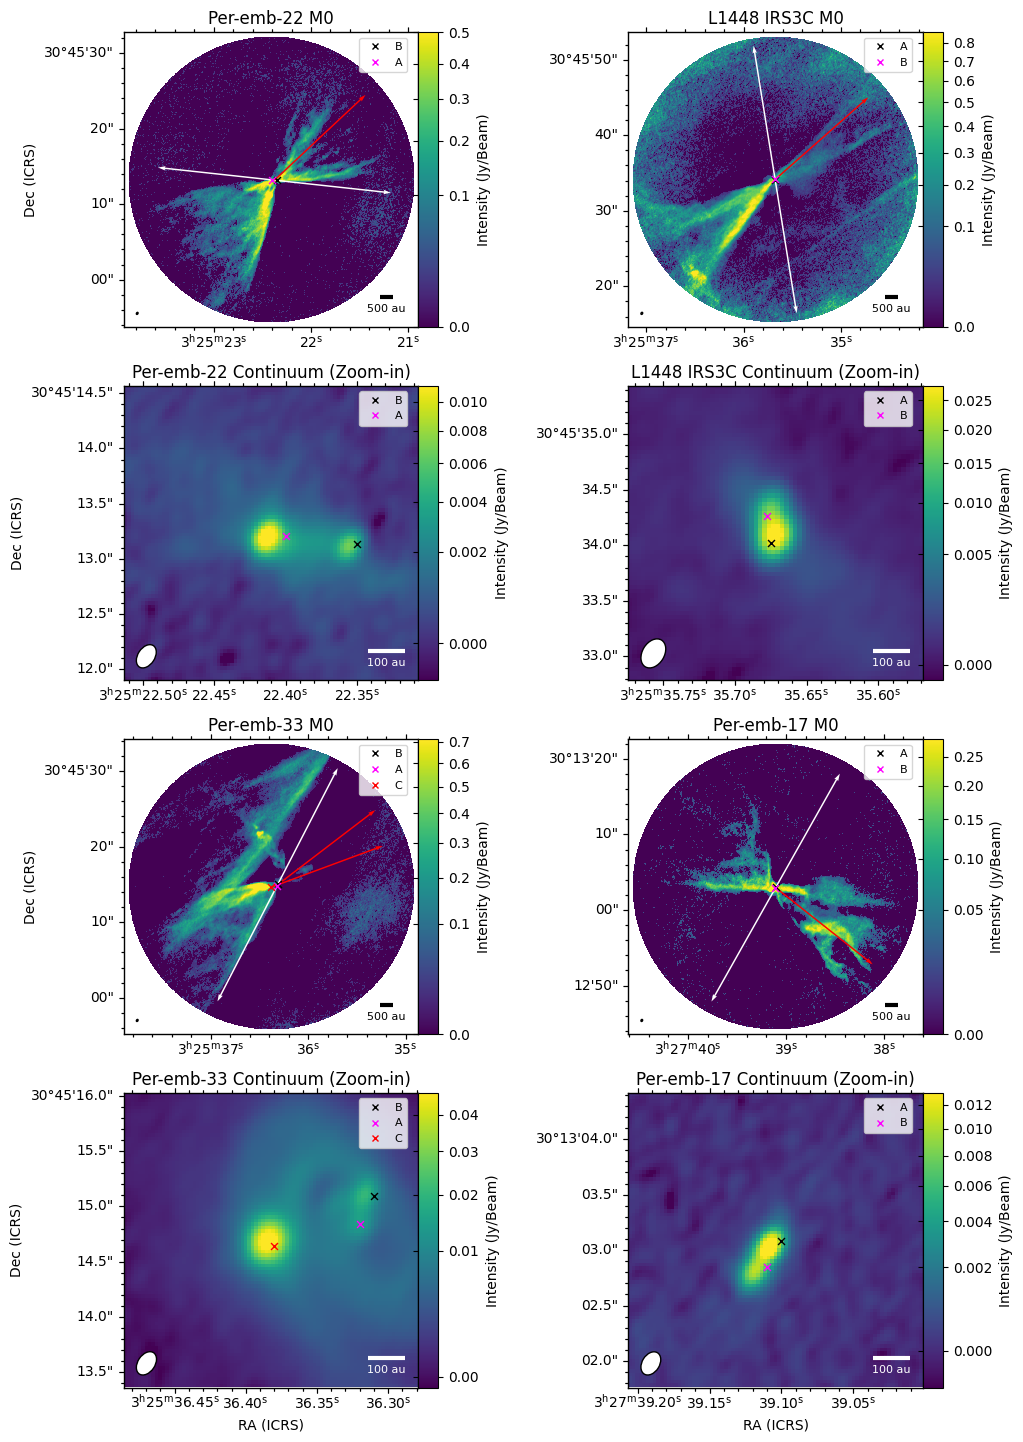

In [8]:
# make_compound_plots(fig_1, "fig_1", rows=1, cols=4, wspace=0.4, hspace=0.1)
# make_compound_plots(fig_2, "fig_2", rows=1, cols=2, wspace=0.4, hspace=0.1)
make_compound_plots(app_1[0:4], "appendix-1-2", rows=4, cols=2)
# make_compound_plots(app_1[15:30], "appendix-2", rows=5, cols=3)
# make_compound_plots(app_1[30::], "appendix-3", rows=5, cols=3)
# make_compound_plots(app_2, "appendix-4", rows=2, cols=3)